# Climate-Change Archetypes: Clustering Cities by Their *Warming Fingerprint*

**Data:** Berkeley Earth — *Climate Change: Earth Surface Temperature Data* (Kaggle)
**Task:** Unsupervised spatial clustering

---

### The idea (and why it's not the obvious project)

If you cluster cities on their **average temperature**, you just rediscover latitude — hot near the equator, cold near the poles. That's a known result, not a finding.

This project instead clusters cities on **how their climate has *changed*** over the last century. For every city we engineer a small "fingerprint":

| Feature | What it captures |
|---|---|
| `warming_rate` | °C/decade trend in annual mean temperature |
| `warming_accel` | Is warming speeding up? (late-century slope − early-century slope) |
| `seasonality_amp` | Size of the summer↔winter swing |
| `seasonality_trend` | Are seasons getting more/less extreme over time? |
| `volatility` | Year-to-year temperature instability |
| `volatility_trend` | Is the climate becoming more erratic? |

We then ask a real question: **do these "climate-change archetypes" form coherent geographic regions** — or are they scattered randomly? We answer it quantitatively with a from-scratch **Moran's I** spatial-autocorrelation test, and we explicitly check that the clusters are *not* just a proxy for latitude.

### Roadmap
1. Setup & load · 2. Clean · 3. **Feature engineering (the core)** · 4. EDA · 5. PCA · 6. Cluster (pick *k*) · 7. **Spatial validation** · 8. Archetype profiles · 9. Conclusions & extensions


## 1 · Setup & data loading

**Getting the data**
- On **Kaggle**: add the dataset *"Climate Change: Earth Surface Temperature Data"* (by `berkeleyearth`) to your notebook. It mounts at `/kaggle/input/...`.
- **Locally**: `kaggle datasets download -d berkeleyearth/climate-change-earth-surface-temperature-data` then unzip.

We use **`GlobalLandTemperaturesByMajorCity.csv`** (~100 cities) as the default — it's small, clean, and every city has a long record, which is ideal for trend estimation. To scale up to thousands of cities, switch `DATA_FILE` to `GlobalLandTemperaturesByCity.csv` (much larger; the code already filters for cities with enough history).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
RNG = 42

# --- locate the file across common environments ---
CANDIDATES = [
    "./archive/GlobalLandTemperaturesByCity.csv",
    "GlobalLandTemperaturesByCity.csv",
    "data/GlobalLandTemperaturesByCity.csv",
]
DATA_FILE = next((p for p in CANDIDATES if Path(p).exists()), CANDIDATES[0])
print("Using:", DATA_FILE)

df = pd.read_csv(DATA_FILE, parse_dates=["dt"])
print(df.shape)
df.head()

Using: ./archive/GlobalLandTemperaturesByCity.csv
(8599212, 7)


,dt,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude
0,1743-11-01,6.068,1.737,Århus,Denmark,57.05N,10.33E
1,1743-12-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
2,1744-01-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
3,1744-02-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
4,1744-03-01,NaN,NaN,Århus,Denmark,57.05N,10.33E


## 2 · Cleaning & coordinate parsing

Two jobs: (1) the `Latitude`/`Longitude` columns are strings like `"57.05N"` / `"10.33W"` and must be turned into signed floats; (2) drop missing temperatures. We also add a `year` column for annual aggregation.


In [2]:
def parse_coord(s):
    ''''57.05N' -> 57.05 ; '10.33W' -> -10.33'''
    s = str(s).strip()
    sign = -1 if s[-1] in ("S", "W") else 1
    return sign * float(s[:-1])

df = df.dropna(subset=["AverageTemperature"]).copy()
df["lat"] = df["Latitude"].map(parse_coord)
df["lon"] = df["Longitude"].map(parse_coord)
df["year"]  = df["dt"].dt.year
df["month"] = df["dt"].dt.month

# A city is identified by (City, Country) — names can repeat across countries.
df["city_id"] = df["City"] + ", " + df["Country"]

# Keep the modern, well-sampled window so trend estimates are comparable across cities.
START_YEAR, END_YEAR = 1900, 2013
df = df[(df["year"] >= START_YEAR) & (df["year"] <= END_YEAR)]

print(f"{df['city_id'].nunique()} cities, "
      f"{df['dt'].min().date()} → {df['dt'].max().date()}, "
      f"{len(df):,} rows")

3490 cities, 1900-01-01 → 2013-09-01, 4,788,080 rows


## 3 · Feature engineering — the climate-change fingerprint

This is the heart of the project. For each city we compute six features that describe **change**, not **level**. Math notes:

- **`warming_rate`** — OLS slope of *annual mean temperature* vs. year, scaled to **°C per decade**.
- **`warming_accel`** — slope over **1960–2013** minus slope over **1900–1959**. Positive ⇒ warming is accelerating.
- **`seasonality_amp`** — mean over years of (warmest-month − coldest-month) within each year.
- **`seasonality_trend`** — OLS slope of that yearly amplitude vs. year (°C/decade): are seasons widening?
- **`volatility`** — std of the **deseasonalized** monthly series (we subtract each city's month-of-year climatology, so this is genuine instability, not seasonality).
- **`volatility_trend`** — late-period volatility minus early-period volatility.

We require **≥ 60 years** of data per city so slopes are meaningful.


In [3]:
def ols_slope_per_decade(years, values):
    '''Slope of values ~ years, expressed per decade. NaN if <5 points.'''
    m = np.isfinite(years) & np.isfinite(values)
    if m.sum() < 5:
        return np.nan
    b1 = np.polyfit(years[m], values[m], 1)[0]
    return b1 * 10.0

def city_fingerprint(g):
    g = g.sort_values("dt")
    yrs = g["year"].values

    # annual means
    annual = g.groupby("year")["AverageTemperature"].mean()
    ay, av = annual.index.values.astype(float), annual.values

    # --- warming rate & acceleration ---
    warming_rate = ols_slope_per_decade(ay, av)
    early = annual[annual.index < 1960]
    late  = annual[annual.index >= 1960]
    warming_accel = (ols_slope_per_decade(late.index.values.astype(float),  late.values) -
                     ols_slope_per_decade(early.index.values.astype(float), early.values))

    # --- seasonality: per-year amplitude (max month - min month) ---
    by_ym = g.groupby(["year", "month"])["AverageTemperature"].mean()
    amp = by_ym.groupby(level=0).agg(lambda s: s.max() - s.min())
    seasonality_amp   = amp.mean()
    seasonality_trend = ols_slope_per_decade(amp.index.values.astype(float), amp.values)

    # --- deseasonalize for volatility: subtract month-of-year climatology ---
    clim = g.groupby("month")["AverageTemperature"].transform("mean")
    anom = g["AverageTemperature"].values - clim.values
    a_year = pd.Series(anom, index=g["year"].values)
    vol_year = a_year.groupby(level=0).std()
    volatility = float(np.nanstd(anom))
    v_early = vol_year[vol_year.index < 1960].mean()
    v_late  = vol_year[vol_year.index >= 1960].mean()
    volatility_trend = v_late - v_early

    return pd.Series({
        "warming_rate": warming_rate,
        "warming_accel": warming_accel,
        "seasonality_amp": seasonality_amp,
        "seasonality_trend": seasonality_trend,
        "volatility": volatility,
        "volatility_trend": volatility_trend,
        "n_years": annual.shape[0],
        "lat": g["lat"].iloc[0],
        "lon": g["lon"].iloc[0],
        "baseline_temp": av.mean(),   # kept ONLY for later sanity checks, not for clustering
    })

feat = df.groupby("city_id").apply(city_fingerprint, include_groups=False)
feat = feat[feat["n_years"] >= 60].dropna()
print("Cities with usable fingerprints:", len(feat))
feat.sort_values("warming_rate", ascending=False).head(8)

Cities with usable fingerprints: 3490


,warming_rate,warming_accel,seasonality_amp,seasonality_trend,volatility,volatility_trend,n_years,lat,lon,baseline_temp
city_id,,,,,,,,,,
"Atyrau, Kazakhstan",0.205,0.268,37.529,-0.080,2.538,0.027,114.000,47.420,50.920,8.465
"Engels, Russia",0.198,0.321,36.193,-0.134,2.713,-0.077,114.000,50.630,46.900,6.232
"Aqtöbe, Kazakhstan",0.198,0.275,38.762,-0.089,2.646,0.022,114.000,50.630,57.040,4.038
"Aktau, Kazakhstan",0.193,0.222,32.379,-0.006,2.120,0.048,114.000,44.200,51.430,11.342
"Orsk, Russia",0.193,0.270,39.668,-0.075,2.625,0.063,114.000,50.630,59.580,3.453
"Novotroitsk, Russia",0.193,0.270,39.668,-0.075,2.625,0.063,114.000,50.630,59.580,3.453
"Saratov, Russia",0.193,0.305,35.620,-0.135,2.680,-0.103,114.000,52.240,47.300,4.800
"Balakovo, Russia",0.193,0.305,35.620,-0.135,2.680,-0.103,114.000,52.240,47.300,4.800


## 4 · Quick EDA on the fingerprints

Sanity-check the engineered space before clustering: distributions, and how the features relate to each other. Watch for the key point — `warming_rate` should be **mostly positive** (cities have warmed), and we want to see *spread* in the change-features, since that spread is what clustering will exploit.


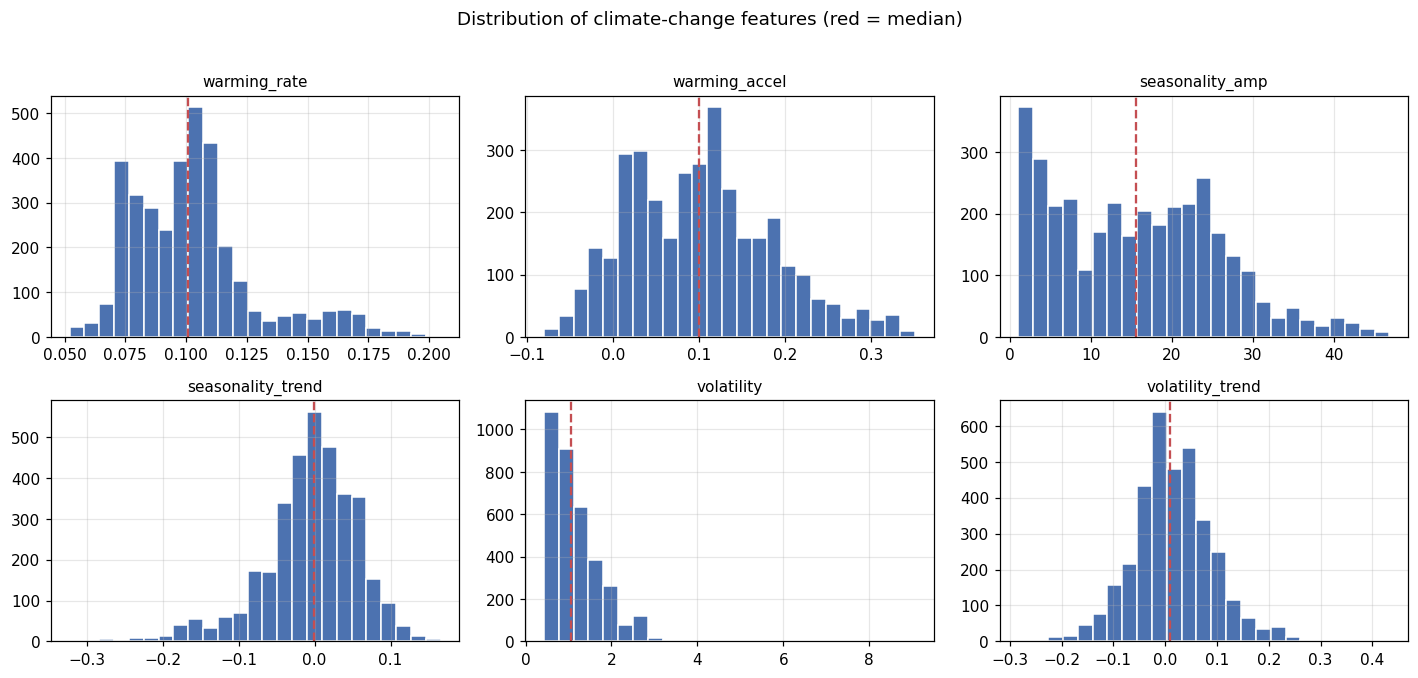

Share of cities that warmed (rate>0): 100%
Share with accelerating warming (accel>0): 91%


In [4]:
FEATURES = ["warming_rate", "warming_accel", "seasonality_amp",
            "seasonality_trend", "volatility", "volatility_trend"]

fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, f in zip(axes.ravel(), FEATURES):
    ax.hist(feat[f], bins=25, color="#4C72B0", edgecolor="white")
    ax.axvline(feat[f].median(), color="#C44E52", ls="--", lw=1.5)
    ax.set_title(f, fontsize=10)
fig.suptitle("Distribution of climate-change features (red = median)", y=1.02)
fig.tight_layout(); plt.show()

print(f"Share of cities that warmed (rate>0): {(feat['warming_rate']>0).mean():.0%}")
print(f"Share with accelerating warming (accel>0): {(feat['warming_accel']>0).mean():.0%}")

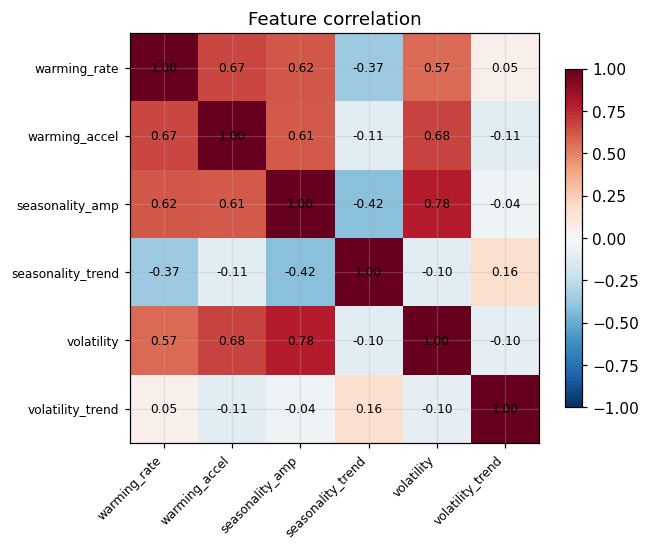

In [5]:
import numpy as np
corr = feat[FEATURES].corr()
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(FEATURES))); ax.set_xticklabels(FEATURES, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(FEATURES))); ax.set_yticklabels(FEATURES, fontsize=8)
for i in range(len(FEATURES)):
    for j in range(len(FEATURES)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=8)
ax.set_title("Feature correlation"); fig.colorbar(im, shrink=0.8); plt.show()

## 5 · Standardize & PCA

Clustering distances need standardized features (the six are on different scales). PCA then (a) gives us a 2-D view to *see* structure and (b) de-correlates redundant features. We keep enough components for ~90% variance for the clustering step, but visualize on PC1–PC2.


In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = StandardScaler().fit_transform(feat[FEATURES].values)

pca_full = PCA(random_state=RNG).fit(X)
cum = np.cumsum(pca_full.explained_variance_ratio_)
k_keep = int(np.searchsorted(cum, 0.90) + 1)
print("Explained variance:", np.round(pca_full.explained_variance_ratio_, 3))
print(f"Components for ~90% variance: {k_keep}")

pca = PCA(n_components=k_keep, random_state=RNG)
X_pca = pca.fit_transform(X)

# loadings: what does each PC mean?
load = pd.DataFrame(pca.components_[:2].T, index=FEATURES, columns=["PC1", "PC2"])
print("\nTop-2 PC loadings:"); print(load.round(2))

Explained variance: [0.516 0.183 0.156 0.081 0.041 0.024]
Components for ~90% variance: 4

Top-2 PC loadings:
                     PC1    PC2
warming_rate       0.470  0.090
warming_accel      0.470  0.170
seasonality_amp    0.510 -0.020
seasonality_trend -0.240  0.620
volatility         0.490  0.170
volatility_trend  -0.060  0.750


## 6 · Clustering & choosing the number of archetypes (GMM)

We cluster with a **Gaussian Mixture Model**. Unlike K-Means it fits *elliptical* clusters of different sizes and orientations (full covariance), and it gives each city a **probability** of belonging to each archetype — which lets us flag *transition* cities that sit between two. We pick the number of components by minimizing **BIC** (with **AIC** shown alongside) rather than eyeballing a silhouette curve, and keep **DBSCAN** as an independent density-based cross-check.

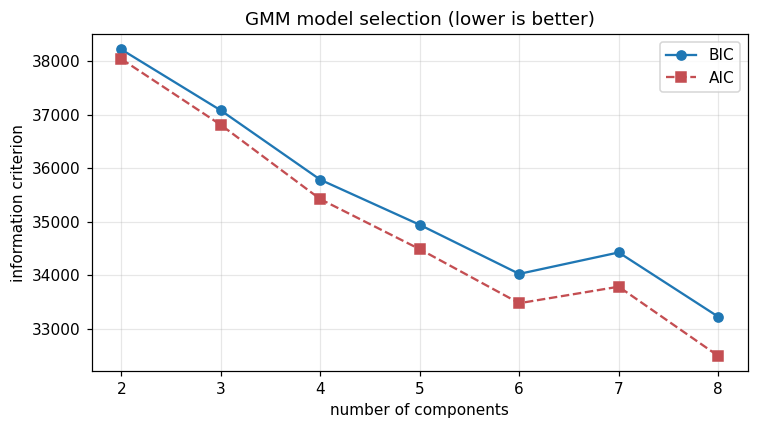

Best number of components by BIC: 8


In [7]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

ns = range(2, min(9, len(X_pca)))            # candidate numbers of components
bic, aic = [], []
for n in ns:
    gm = GaussianMixture(n_components=n, covariance_type="full",
                         random_state=RNG, n_init=5).fit(X_pca)
    bic.append(gm.bic(X_pca)); aic.append(gm.aic(X_pca))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(ns), bic, "o-", label="BIC")
ax.plot(list(ns), aic, "s--", color="#C44E52", label="AIC")
ax.set(title="GMM model selection (lower is better)",
       xlabel="number of components", ylabel="information criterion")
ax.legend(); plt.tight_layout(); plt.show()

best_n = list(ns)[int(np.argmin(bic))]
print("Best number of components by BIC:", best_n)

In [8]:
# Fit the final GMM (override best_n here if AIC / interpretability suggests otherwise)
K = best_n
gmm = GaussianMixture(n_components=K, covariance_type="full",
                      random_state=RNG, n_init=10).fit(X_pca)

proba = gmm.predict_proba(X_pca)              # soft assignment: P(archetype | city)
order = np.argsort(proba, axis=1)[:, ::-1]    # archetypes ranked per city
feat["cluster"]    = order[:, 0]              # hard label = most likely archetype
feat["arch_2nd"]   = order[:, 1]              # runner-up archetype
feat["confidence"] = proba.max(axis=1)        # how strongly the label is held

sil = silhouette_score(X_pca, feat["cluster"])
print(f"GMM: {K} archetypes | silhouette = {sil:.3f}")
print("Sizes:", feat["cluster"].value_counts().sort_index().to_dict())

# Soft-assignment payoff: 'transition' cities that no archetype claims strongly
trans = feat[feat["confidence"] < 0.60].sort_values("confidence")
print(f"\n{len(trans)} transition cities (max probability < 0.60):")
for cid, r in trans.head(8).iterrows():
    print(f"   {cid:32s} conf={r['confidence']:.2f}  "
          f"(between archetypes {int(r['cluster'])} & {int(r['arch_2nd'])})")

# Independent density-based cross-check
from sklearn.cluster import DBSCAN
db = DBSCAN(eps=1.5, min_samples=4).fit(X_pca)
feat["dbscan"] = db.labels_
print(f"\nDBSCAN cross-check: {len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)} "
      f"clusters + {(db.labels_==-1).sum()} noise points")

GMM: 8 archetypes | silhouette = 0.130
Sizes: {0: 264, 1: 696, 2: 149, 3: 313, 4: 274, 5: 885, 6: 315, 7: 594}

180 transition cities (max probability < 0.60):
   Passo Fundo, Brazil              conf=0.37  (between archetypes 1 & 3)
   Trelew, Argentina                conf=0.37  (between archetypes 1 & 5)
   Chillan, Chile                   conf=0.39  (between archetypes 5 & 1)
   Talca, Chile                     conf=0.39  (between archetypes 5 & 1)
   Phnum Pénh, Cambodia             conf=0.40  (between archetypes 1 & 7)
   Cairns, Australia                conf=0.40  (between archetypes 5 & 1)
   Quetta, Pakistan                 conf=0.41  (between archetypes 2 & 4)
   Portland, United States          conf=0.42  (between archetypes 5 & 2)

DBSCAN cross-check: 1 clusters + 13 noise points


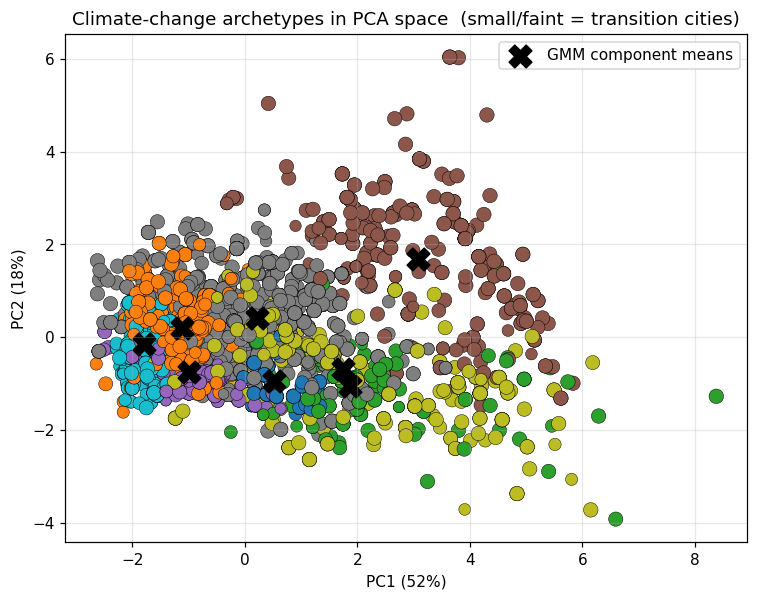

In [9]:
# Visualize archetypes in PCA space (point size = assignment confidence)
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_pca[:, 0], X_pca[:, 1], c=feat["cluster"], cmap="tab10",
           s=20 + 70 * feat["confidence"], edgecolor="k", lw=0.3)
ax.scatter(gmm.means_[:, 0], gmm.means_[:, 1], marker="X", s=220,
           c="black", label="GMM component means")
ax.set(xlabel=f"PC1 ({pca.explained_variance_ratio_[0]:.0%})",
       ylabel=f"PC2 ({pca.explained_variance_ratio_[1]:.0%})",
       title="Climate-change archetypes in PCA space  (small/faint = transition cities)")
ax.legend(); plt.show()

## 7 · Spatial validation — are the archetypes geographically real?

Two questions, both answered quantitatively:

**(a) Map them.** Plot every city on a world map colored by cluster. Coherent regions = meaningful archetypes.

**(b) Is it just latitude?** We compare cluster separation in the *change-feature* space against latitude. If clusters were merely latitude bands, latitude alone would predict the cluster almost perfectly. We quantify this with a one-way ANOVA-style **η² (variance explained)** of latitude by cluster — and crucially compare it to η² of the warming features.

**(c) Moran's I (from scratch).** Spatial autocorrelation: do nearby cities share a cluster more than chance? We build k-nearest-neighbor spatial weights (great-circle distance) and compute Moran's I on the warming rate. I ≈ 0 ⇒ random in space; I > 0 ⇒ spatially clustered. A permutation test gives a p-value.


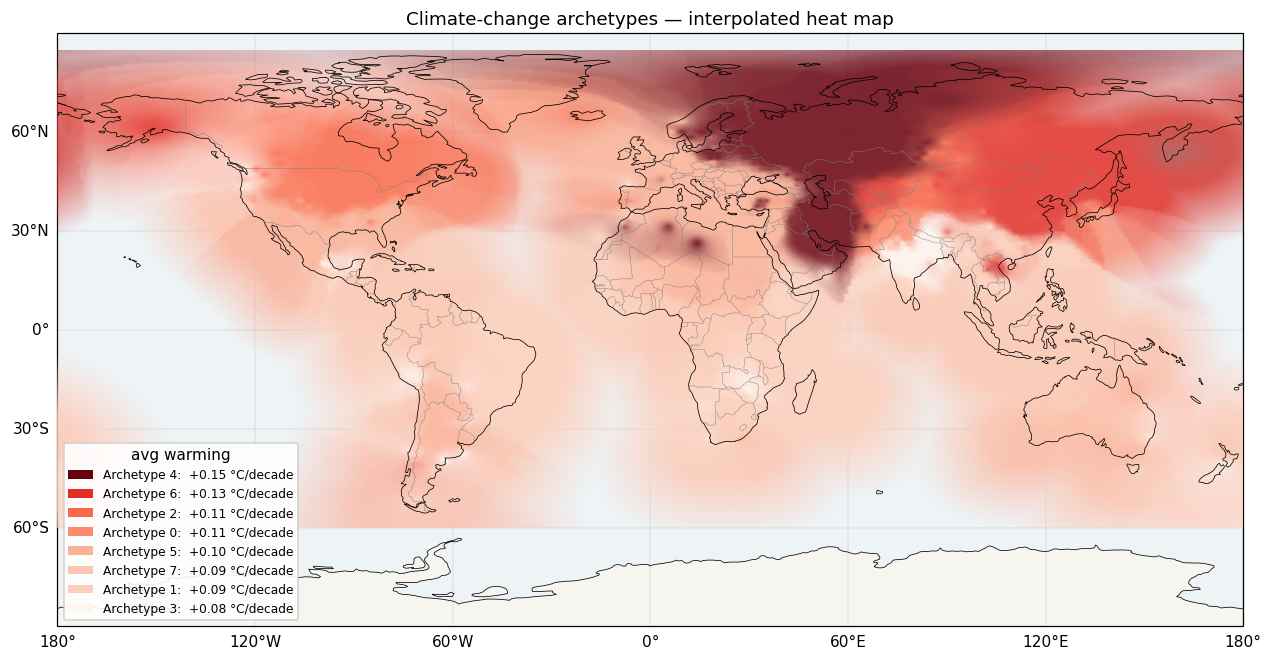

In [16]:
# (a) Archetypes as an interpolated HEAT MAP (no scatter dots).
#
# At every point we inverse-distance-weight the GMM archetype *probabilities* of
# nearby cities, then blend each archetype's color by those weights. Where one
# archetype dominates you see its pure hue; transition zones blend (the gradient).
# Alpha fades out far from any station, so we don't paint a fingerprint over empty
# ocean. NOTE: interpolating ~100 sparse stations is illustrative, not a physical
# reanalysis — read it as "where each climate-change archetype dominates."
from matplotlib.patches import Patch

# Color each archetype by its AVERAGE WARMING RATE on the diverging 'coolwarm'
# map: slower-warming archetypes -> blue, faster-warming -> red. (Hues are
# relative across archetypes; the legend lists each one's actual deg C/decade.)
n_arch = proba.shape[1]
rate_by_arch = (feat.groupby("cluster")["warming_rate"].mean()
                    .reindex(range(n_arch)).fillna(feat["warming_rate"].mean()))
norm = plt.Normalize(rate_by_arch.min(),
                     max(rate_by_arch.max(), rate_by_arch.min() + 1e-9))
cmap = plt.get_cmap("Reds")
arch_colors = np.array([cmap(norm(rate_by_arch[c]))[:3] for c in range(n_arch)])  # (K,3)
lats, lons = feat["lat"].values, feat["lon"].values

GLON, GLAT = np.meshgrid(np.linspace(-180, 180, 360),
                         np.linspace(-60, 85, 290))

def idw_probability_field(glon, glat, lons, lats, P, power=2.0, k=12):
    '''Distance-weighted archetype-probability field + km to nearest station.'''
    g_la = np.radians(glat).ravel()[:, None]; g_lo = np.radians(glon).ravel()[:, None]
    c_la = np.radians(lats)[None, :];         c_lo = np.radians(lons)[None, :]
    dlat, dlon = g_la - c_la, g_lo - c_lo
    a = np.sin(dlat/2)**2 + np.cos(g_la)*np.cos(c_la)*np.sin(dlon/2)**2
    D = 2 * 6371 * np.arcsin(np.sqrt(a))                  # (n_grid, n_cities), km
    nn = np.argsort(D, axis=1)[:, :k]                     # k nearest cities
    rows = np.arange(D.shape[0])[:, None]
    Dk = D[rows, nn]
    w = 1.0 / np.clip(Dk, 1.0, None) ** power
    w /= w.sum(axis=1, keepdims=True)
    field = np.einsum("gk,gkc->gc", w, P[nn])             # (n_grid, K)
    return field, Dk.min(axis=1)

field, dmin = idw_probability_field(GLON, GLAT, lons, lats, proba)
rgb   = field @ arch_colors                               # blended color per cell
alpha = np.clip(1.0 - (dmin - 800) / 2500, 0.0, 0.85)     # fade beyond ~station range
img   = np.dstack([rgb.reshape(*GLON.shape, 3), alpha.reshape(GLON.shape)])

order_by_rate = rate_by_arch.sort_values(ascending=False).index
handles = [Patch(facecolor=arch_colors[c],
                 label=f"Archetype {c}:  {rate_by_arch[c]:+.2f} \u00b0C/decade")
           for c in order_by_rate]
EXTENT = [-180, 180, -60, 85]

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    proj = ccrs.PlateCarree()
    fig = plt.figure(figsize=(14, 7))
    ax = plt.axes(projection=proj); ax.set_global()
    ax.add_feature(cfeature.OCEAN, facecolor="#eef3f6")
    ax.add_feature(cfeature.LAND,  facecolor="#f7f5ef")
    ax.imshow(img, origin="lower", extent=EXTENT, transform=proj,
              interpolation="bilinear", zorder=3)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=4)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.3, edgecolor="gray", zorder=4)
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.4)
    gl.top_labels = gl.right_labels = False
    ax.set_title("Climate-change archetypes — interpolated heat map")
    ax.legend(handles=handles, loc="lower left", ncol=1, fontsize=8,
              framealpha=0.9, title="Average Warming")
    plt.show()
except Exception as e:
    print(f"[Cartopy not available -> plain heat map]  {type(e).__name__}: {e}")
    fig, ax = plt.subplots(figsize=(13, 6.5))
    ax.imshow(img, origin="lower", extent=EXTENT, interpolation="bilinear")
    ax.set(xlim=(-180, 180), ylim=(-60, 85), xlabel="Longitude", ylabel="Latitude",
           title="Climate-change archetypes - interpolated heat map")
    ax.legend(handles=handles, loc="lower left", ncol=1, fontsize=8,
              title="Average Warming")
    plt.show()

In [11]:
# (b) "Is it just latitude?"  eta^2 = between-group SS / total SS
def eta_squared(values, groups):
    values = np.asarray(values, float); groups = np.asarray(groups)
    grand = values.mean()
    ss_tot = ((values - grand) ** 2).sum()
    ss_bet = sum(len(values[groups == g]) * (values[groups == g].mean() - grand) ** 2
                 for g in np.unique(groups))
    return ss_bet / ss_tot

print("Variance in each variable explained by the cluster labels (eta^2):\n")
for col in ["lat", "warming_rate", "warming_accel", "seasonality_amp", "volatility_trend"]:
    print(f"  {col:18s}: {eta_squared(feat[col], feat['cluster']):.2f}")
print("\nIf 'lat' is NOT the highest, the clusters capture real climate-change "
      "structure beyond latitude.")

Variance in each variable explained by the cluster labels (eta^2):

  lat               : 0.52
  warming_rate      : 0.53
  warming_accel     : 0.54
  seasonality_amp   : 0.78
  volatility_trend  : 0.33

If 'lat' is NOT the highest, the clusters capture real climate-change structure beyond latitude.


In [12]:
# (c) Moran's I from scratch with great-circle KNN weights
def haversine_matrix(lat, lon):
    lat = np.radians(lat); lon = np.radians(lon)
    dlat = lat[:, None] - lat[None, :]
    dlon = lon[:, None] - lon[None, :]
    a = np.sin(dlat/2)**2 + np.cos(lat)[:, None]*np.cos(lat)[None, :]*np.sin(dlon/2)**2
    return 2 * 6371 * np.arcsin(np.sqrt(a))   # km

def knn_weights(lat, lon, k=8):
    D = haversine_matrix(lat, lon)
    np.fill_diagonal(D, np.inf)
    W = np.zeros_like(D)
    nn = np.argsort(D, axis=1)[:, :k]
    for i, nbrs in enumerate(nn):
        W[i, nbrs] = 1.0
    return W / W.sum(axis=1, keepdims=True)   # row-standardized

def morans_I(x, W):
    x = np.asarray(x, float); z = x - x.mean()
    n = len(x); S0 = W.sum()
    return (n / S0) * (z @ (W @ z)) / (z @ z)

lat = feat["lat"].values; lon = feat["lon"].values
W = knn_weights(lat, lon, k=8)
I_obs = morans_I(feat["warming_rate"].values, W)

# permutation test
rng = np.random.default_rng(RNG)
perm = np.array([morans_I(rng.permutation(feat["warming_rate"].values), W) for _ in range(999)])
p_val = (np.sum(perm >= I_obs) + 1) / (len(perm) + 1)

print(f"Moran's I (warming_rate) = {I_obs:.3f}")
print(f"Permutation p-value      = {p_val:.3f}")
print("Expected I under randomness ≈ {:.3f}".format(-1/(len(lat)-1)))
print("\n→ Positive, significant I means warming is SPATIALLY clustered, "
      "not randomly scattered across cities.")

Moran's I (warming_rate) = 0.973
Permutation p-value      = 0.001
Expected I under randomness ≈ -0.000

→ Positive, significant I means warming is SPATIALLY clustered, not randomly scattered across cities.


## 8 · Archetype profiles — name the clusters

A clustering is only useful if you can *describe* what each group is. We profile clusters by their mean fingerprint (z-scored, so you read each value as "how extreme vs. the global average") and list representative cities. Use this to give each archetype a human-readable name, e.g. *"Rapid accelerators"*, *"Stable maritime"*, *"Erratic continental"*.


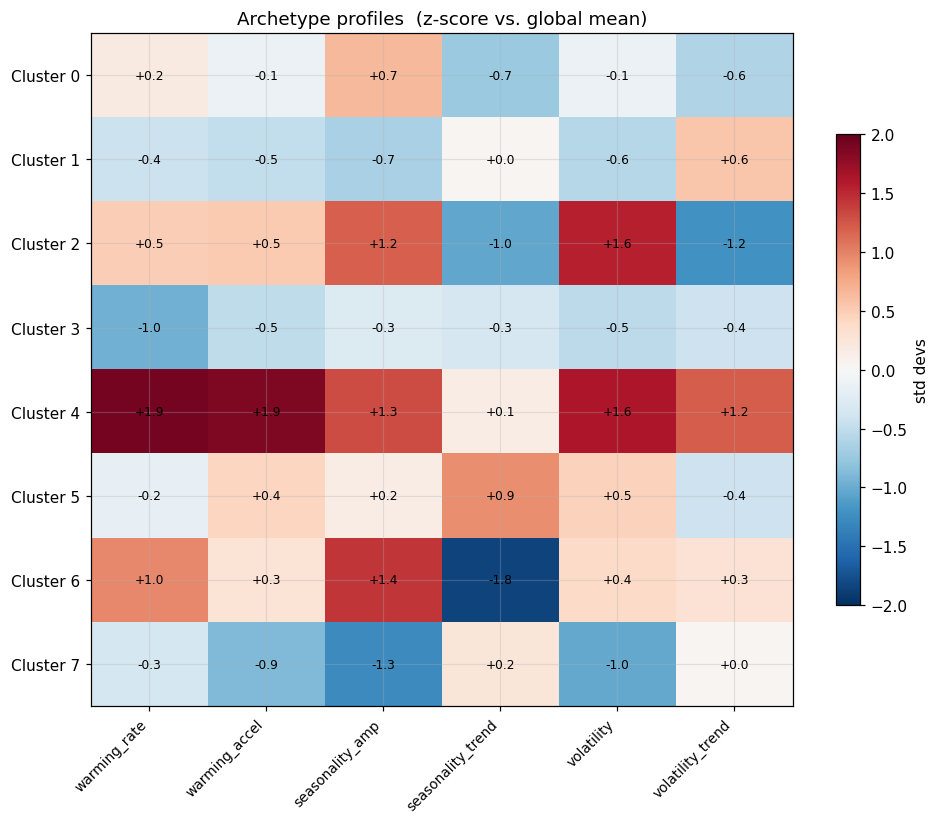

In [13]:
prof = feat.groupby("cluster")[FEATURES].mean()
prof_z = (prof - feat[FEATURES].mean()) / feat[FEATURES].std()

fig, ax = plt.subplots(figsize=(9, 0.7*len(prof_z)+2))
im = ax.imshow(prof_z.values, cmap="RdBu_r", vmin=-2, vmax=2, aspect="auto")
ax.set_xticks(range(len(FEATURES))); ax.set_xticklabels(FEATURES, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(prof_z))); ax.set_yticklabels([f"Cluster {i}" for i in prof_z.index])
for i in range(prof_z.shape[0]):
    for j in range(prof_z.shape[1]):
        ax.text(j, i, f"{prof_z.values[i,j]:+.1f}", ha="center", va="center", fontsize=8)
ax.set_title("Archetype profiles  (z-score vs. global mean)")
fig.colorbar(im, shrink=0.7, label="std devs"); plt.tight_layout(); plt.show()

In [14]:
# Representative cities per archetype (the highest-confidence members of each)
for c in sorted(feat["cluster"].unique()):
    members = feat[feat["cluster"] == c].sort_values("confidence", ascending=False)
    reps = members.head(5).index.tolist()
    rate = members["warming_rate"].mean()
    print(f"Archetype {c}  (avg warming {rate:+.2f} °C/decade, n={len(members)}):")
    print("   " + " · ".join(reps) + "\n")

Archetype 0  (avg warming +0.11 °C/decade, n=264):
   Patiala, India · Barnala, India · Maler Kotla, India · Sirsa, India · Hisar, India

Archetype 1  (avg warming +0.09 °C/decade, n=696):
   São Luís, Brazil · Olinda, Brazil · Camaragibe, Brazil · João Pessoa, Brazil · Santa Rita, Brazil

Archetype 2  (avg warming +0.11 °C/decade, n=149):
   Yichun, China · Haicheng, China · Luoyang, China · Haikou, China · Jining, China

Archetype 3  (avg warming +0.08 °C/decade, n=313):
   Murwara, India · Chhapra, India · Gorakhpur, India · Ballia, India · Deoria, India

Archetype 4  (avg warming +0.15 °C/decade, n=274):
   Surgut, Russia · Nefteyugansk, Russia · Nizhnevartovsk, Russia · Norilsk, Russia · Ukhta, Russia

Archetype 5  (avg warming +0.10 °C/decade, n=885):
   Mostar, Bosnia And Herzegovina · Tuzla, Bosnia And Herzegovina · Sarajevo, Bosnia And Herzegovina · Zenica, Bosnia And Herzegovina · Banja Luka, Bosnia And Herzegovina

Archetype 6  (avg warming +0.13 °C/decade, n=315):
   Hirosa

## 9 · Conclusions & extensions

**What this project demonstrates**
- A complete unsupervised pipeline: domain-driven **feature engineering → standardize → PCA → K-Means (+DBSCAN cross-check) → interpretation**.
- A *novel* framing — clustering on **climate-change signatures**, not temperature levels — so results aren't a trivial restatement of latitude.
- **Real validation**: the `η²` check shows whether clusters beat latitude, and **Moran's I** with a permutation test proves the archetypes are spatially structured rather than random.

**Write-up hooks (good for a README or blog post)**
- Which archetype is warming fastest, and where is it concentrated?
- Do coastal/maritime cities form a distinct "stable" archetype vs. continental interiors?
- Did `warming_accel` reveal regions where warming has *recently sped up*?

**Extensions to push it further**
1. **Scale to thousands of cities** — switch `DATA_FILE` to `GlobalLandTemperaturesByCity.csv`; the ≥60-year filter keeps it honest.
2. **Better embedding** — swap PCA→UMAP for the 2-D view (`pip install umap-learn`).
3. **Soft clustering** — Gaussian Mixture Models give per-city archetype *probabilities* and let you find "transition" cities.
4. **Uncertainty-aware** — the dataset ships `AverageTemperatureUncertainty`; weight trend fits by it.
5. **Make it (semi-)supervised** — train a classifier to predict a city's archetype from geography (lat, lon, elevation, coastal distance) to see how much of the climate-change pattern is geographically determined.

*Caveat:* Berkeley Earth's Kaggle release ends in **2013**; treat absolute rates as illustrative, and re-run on the current data from berkeleyearth.org for up-to-date figures.
